# 04 - Abstention, calibration, and the verification loop

The interesting question is not how often each arm is right but whether it knows
when it is wrong -- and whether, when it does not know, it declines. On fields the
generator genuinely omitted, abstaining is the *correct* output.

In [1]:
import sys, os
os.environ.setdefault("OMP_NUM_THREADS", "2")
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import torch; torch.set_num_threads(2)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
print("torch", torch.__version__)


torch 2.13.0+cpu


In [2]:
import pathlib
T = pathlib.Path("../results/tables")
pd.read_csv(T / "abstention.csv")

,arm,coverage,absent_abstain_rate,n_absent,present_emit_rate,n_present,top_abstain_reason,top_abstain_count,mean_verify_iters
0,generative,0.890938,0.496815,314,0.933125,2886,no_candidate,349,0.000000
1,generative_verify,0.001250,1.000000,314,0.001386,2886,checks_failed,2847,0.889687
2,heuristic,0.755000,1.000000,314,0.837145,2886,no_candidate,739,0.031563
3,llm_stub,0.745938,1.000000,314,0.827096,2886,no_candidate,813,0.000000
4,span_only,0.916250,0.789809,314,0.993070,2886,no_candidate,268,0.000000
5,span_verify,0.864062,0.971338,314,0.954955,2886,no_candidate,268,0.070938
6,span_verify_norm,0.864062,0.971338,314,0.954955,2886,no_candidate,268,0.070938


In [3]:
pd.read_csv(T / "calibration.csv")

,arm,ece,ace,mce,brier,nll,aurc,error_auroc,mean_confidence,n_calibration
0,generative,0.416965,0.416965,0.588585,0.192033,0.568272,0.998286,0.845911,0.417667,2851.0
1,generative_verify,0.066773,0.496328,0.566596,0.250818,0.694731,0.270833,0.750000,0.566773,4.0
2,heuristic,0.140415,0.136552,0.542830,0.084644,0.428499,0.020874,0.670352,0.838889,2416.0
3,llm_stub,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,span_only,0.024006,0.025422,0.099913,0.044552,0.155089,0.008535,0.905418,0.917389,2932.0
5,span_verify,0.069292,0.069292,0.433785,0.036183,0.126196,0.001377,0.905755,0.918412,2765.0
6,span_verify_norm,0.069292,0.069292,0.433785,0.036183,0.126196,0.001377,0.905755,0.918412,2765.0


`ece` uses equal-width bins and `ace` equal-mass ones. With confidences piled
near 1.0 most equal-width bins are nearly empty, so `ace` is the more trustworthy
of the two and both are shown so the disagreement is visible.

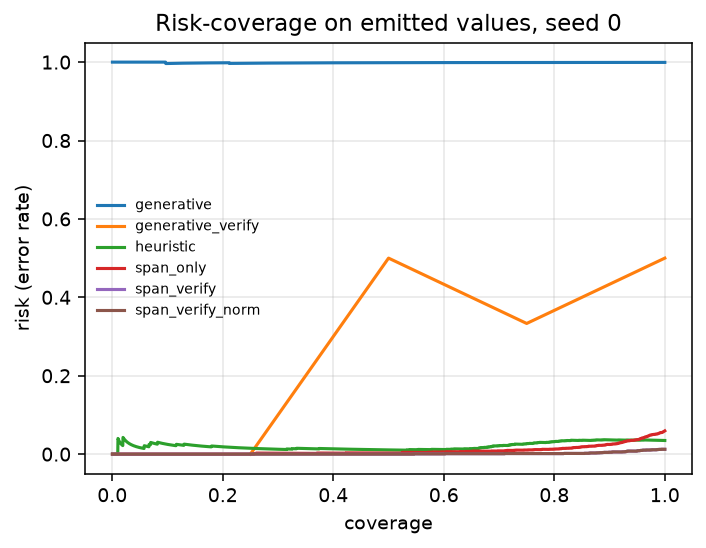

In [4]:
from IPython.display import Image
Image(filename="../results/figures/risk_coverage.png")

### What the loop actually did

Every rejection is counted. `verify_arith_ok_frac` is the fraction of documents
where the arithmetic check *could* run and passed after repair; the check does not
apply at all when the generator dropped the subtotal or the tax, and that case is
`NaN` rather than a pass.

In [5]:
runs = pd.read_csv(T / "seed_runs.csv")
cols = ["arm", "seed", "verify_iters_per_doc", "verify_reselections_per_doc",
        "verify_arith_checked_frac", "verify_arith_ok_frac", "coverage"]
runs[[c for c in cols if c in runs.columns]]

,arm,seed,verify_iters_per_doc,verify_reselections_per_doc,verify_arith_checked_frac,verify_arith_ok_frac,coverage
0,generative,0,0.0000,0.0000,0.0000,NaN,0.890938
1,generative,1,0.0000,0.0000,0.0000,NaN,0.874375
2,generative,2,0.0000,0.0000,0.0000,NaN,0.890312
3,generative_verify,0,7.1175,0.0000,0.0000,NaN,0.001250
4,generative_verify,1,6.9900,0.0000,0.0000,NaN,0.000625
5,generative_verify,2,7.1075,0.0000,0.0000,NaN,0.001875
6,heuristic,0,0.2725,0.2525,0.7775,0.951768,0.755000
7,heuristic,1,0.3375,0.3075,0.8350,0.934132,0.756250
8,heuristic,2,0.3450,0.3200,0.7750,0.925806,0.761563
9,llm_stub,0,0.0000,0.0000,0.0000,NaN,0.745938


### Efficiency, measured

The axis is decode cost, and it is structural: a span head emits two indices in a
fixed number of sequential steps; a character decoder emits `L` characters in `L`
sequential steps per field. The exponent is fitted from measurements.

In [6]:
pd.read_csv(T / "efficiency.csv")

,arm,head,batch_size,seq_len,params,encoder_params,head_params,mmacs,encoder_mmacs,head_mmacs,latency_ms,iqr_ms,latency_per_doc_ms,macs_per_ms,n_warmup,n_repeats,latency_reduction_vs_generative,params_reduction_vs_generative,macs_reduction_vs_generative
0,span_verify,span,1,154,108892,107852,1040,17.326848,17.169152,0.157696,17.72595,4.745350,17.725950,0.977485,10,30,9.306322,1.84717,7.258041
1,span_verify,span,8,154,108892,107852,1040,96.115712,94.854144,1.261568,99.52280,10.074450,12.440350,0.965766,10,30,3.331480,1.84717,10.025132
2,generative,generative,1,154,201142,107852,93290,125.758976,17.169152,108.589824,164.96340,12.242200,164.963400,0.762345,10,30,1.000000,1.00000,1.000000
3,generative,generative,8,154,201142,107852,93290,963.572736,94.854144,868.718592,331.55820,24.376475,41.444775,2.906195,10,30,1.000000,1.00000,1.000000


In [7]:
pd.read_csv(T / "decode_scaling.csv")

,head,dec_max_len,latency_ms,iqr_ms,batch_size,seq_len,fitted_exponent
0,span,4,82.84395,8.182775,8,144,0.077604
1,span,8,80.03080,8.917550,8,144,0.077604
2,span,12,117.54825,29.628575,8,144,0.077604
3,span,16,82.62060,8.194475,8,144,0.077604
4,span,20,91.56605,16.981725,8,144,0.077604
5,span,24,96.37210,30.300675,8,144,0.077604
6,generative,4,92.15400,10.601075,8,144,0.755079
7,generative,8,175.14500,54.250600,8,144,0.755079
8,generative,12,211.15910,45.668475,8,144,0.755079
9,generative,16,259.29020,10.213575,8,144,0.755079


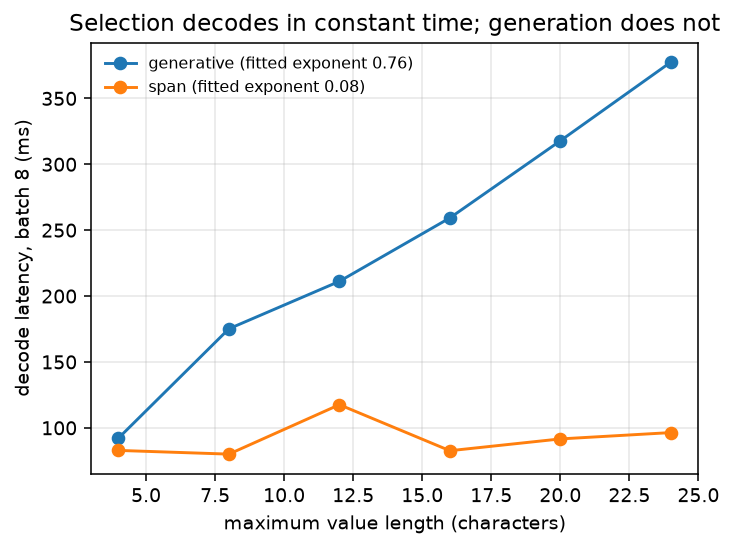

In [8]:
Image(filename="../results/figures/decode_scaling.png")

In [9]:
pd.read_csv(T / "baseline_cost.csv")

,arm,metric,value,iqr_ms,n_docs,note
0,heuristic,latency_per_doc_ms,7.522698,55.5819,40,"variant row_first, warmup 2"
1,llm_stub,prompt_tokens_per_doc,1119.400000,NaN,40,"8 calls/doc, whitespace tokens, lower bound"
2,span_verify,prompt_tokens_per_doc,0.000000,NaN,40,no provider call; local model
